# Woche 5: Erklärbare KI: Modellagnostische Erklärbarkeit


## Aufgabe 1 - Local Surrogate Models
### Aufgabe 1.1 - Sind die folgenden Aussagen korrekt? Falls nicht, begründen Sie bitte kurz (max 3 Sätze).


1. Robuste lokale Erklärungsmethoden sollten ähnliche Erklärungen für ähnliche Beobachtungen zurückgeben.
2. Surrogatmodelle, die von LIME erzeugt werden, sollten für den gesamten Trainingsdatensatz dieselben Vorhersagen wie das zu erklärende Modell liefern.
3. Die Wahl des Stichprobenverfahrens und die Definition von Lokalität sind wichtige Hyperparameter von LIME, die einen großen Einfluss auf das Verhalten der Methode haben.
4. LIME erfordert keine Anpassungen, um auf Deep-Learning-Modelle für Bilddaten anwendbar zu sein.
5. LIME erfordert, dass das Surrogatmodell alle verfügbaren Merkmale verwendet - eine Auswahl von Merkmalen ist nicht erlaubt.
6. Wenn die Kernbreite für den Exponentialkern auf Unendlich gesetzt wird, erhalten alle Beobachtungen unabhängig von ihrem Abstand zu x ein Nähe-Maß/Gewicht von 1.

### Hausaufgabe 1.2 - LIME
Eine Versicherungsgesellschaft möchte monatliche Prämien für eine Berufsunfähigkeitsversicherung mit einem ML-Modell auf der Grundlage der Rente, des Alters, der Berufsart und des Familienstands berechnen. Ein geeignetes Modell $\hat{f}$ wurde bereits mit einem großen Kundendatensatz trainiert, aber für die Veröffentlichung bedarf es der Genehmigung durch die Behörden. Die Regulierungsbehörden testen das Modell, indem sie LIME (mit Exponentialkern) verwenden, um eine Erklärung für typische und wichtige Kunden zu liefern. Eine dieser Testinstanzen x ist eine 21-jährige Frau, die in der ersten Zeile der folgenden Tabelle dargestellt ist.

1. Die Regulatoren haben bereits neue Instanzen zum trainieren des Surrogatmodells generiert. Zur Einfachheit nehmen wir an, dass drei Instanzen genug sind, um das Modell zu trainieren. $\phi_{\sigma}(\textbf{z})$ ist dabei der Exponentialkern als Nachbarschaftsmaß für eine spezifische Kernbreite $\sigma$ und $d$ ist die Gower-Distanz.

|                   | Rente | Alter | Art der Arbeit | Familienstand | $\hat{f}$ | $ \phi_{\sigma = 0,15}(\textbf{z}) $ | $ \phi_{\sigma = 0,15}(\textbf{z}) $ | $ \phi_{\sigma = 0,5}(\textbf{z}) $ |
|-------------------|-------|-------|----------------|---------------|-----------|--------------------------------------|--------------------------------------|-------------------------------------|
| $ \textbf{x}$     | 1800  | 21    | Büro           | ledig         | 30.6      | -                                    | -                                    | -                                   |
| $ \textbf{z}_{1}$ | 1600  | 21    | Büro           | verheiratet   | 25,8      | 0,25                                 | 0,06                                 | 0,78                                |
| $ \textbf{z}_{2}$ | 2200  | 32    | Büro           | verheiratet   | 85,2      | 0,32                                 | 0,01                                 | 0,66                                |
| $ \textbf{z}_{3}$ | 1200  | 23    | körperlich     | ledig         | 74,9      | 0,49                                 | 0,00                                 | 0,38                                |

Wie beeinflusst die Kernbreite $\sigma$ das Nachbarschaftsmaß? War passiert, wenn die Kernbreite zu klein gesetzt wird?

2. Die Zulassungsbehörde hat zwei unterschiedliche Surrogatmodelle ($g_{1}$ und $g_{2}$) trainiert auf den neu gewichteten Daten trainiert (hier, 3 Datenpunkte). Die folgende Tabelle vergleicht die Vorhersage von $\hat{f}$ mit den Vorhersagen der beiden Surrogatmodelle. Welches Surrogatmodell ist besser geeignet? Berechnen sie die lokale Wiedergabetreue für beide Surrogatmodelle mit den Gewichten aus 1) für $\sigma = 0,15$. _Hinweis_: Nutzen Sie $\mathcal{L}(\hat{f}, g, \phi_{\textbf{x}})$ aus der Vorlesung.
3. Das Surrogatmodell $g_{1}$ ist ein lineares Modell für alle drei Merkmale, während $g_{2}$ ein Random Forest mit 500 Bäumen ist. Bleiben Sie bei Ihrer Einschätzung aus 2)?
4. Diskutieren Sie kurz, ob für die Bewertung der Wiedergabetreue in 2) die Nutzung eines neu gesamplten Datensatzes anstelle des Trainingsdatensatzes für die Surrogatmodelle sinnvoll ist.

### Aufgabe 1.3 - LIME Implementierung und Visualisierung

Run `get_grid` ...
Run `plot_grid` ...


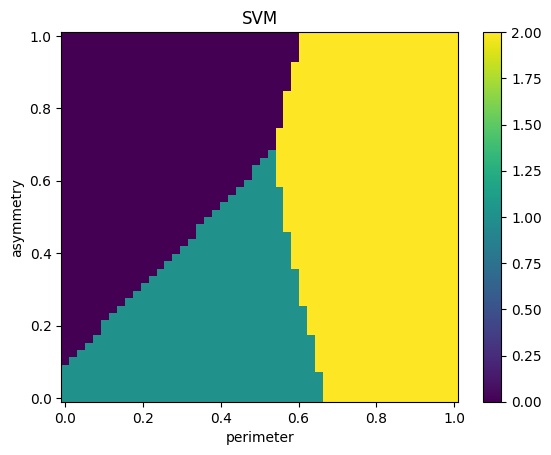

Run `sample_points` ...
Run `plot_points_in_grid` ...


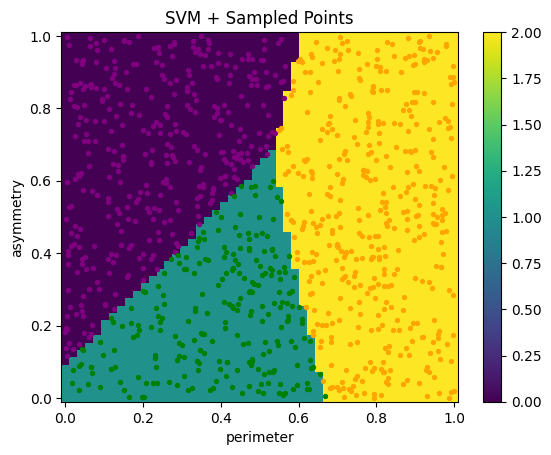

Run `weight_points` ...
Run `plot_points_in_grid` ...


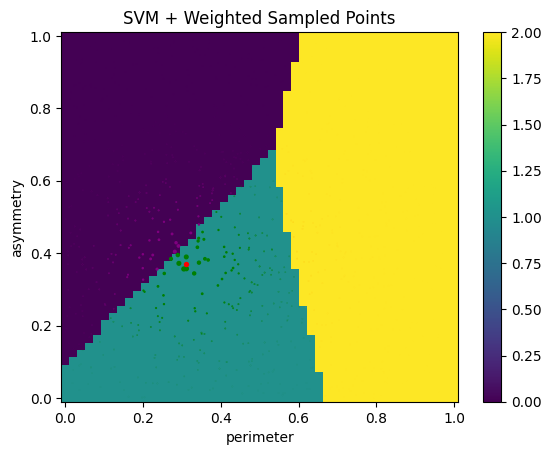

Run `fit_explainer_model` ...
Compare models ...


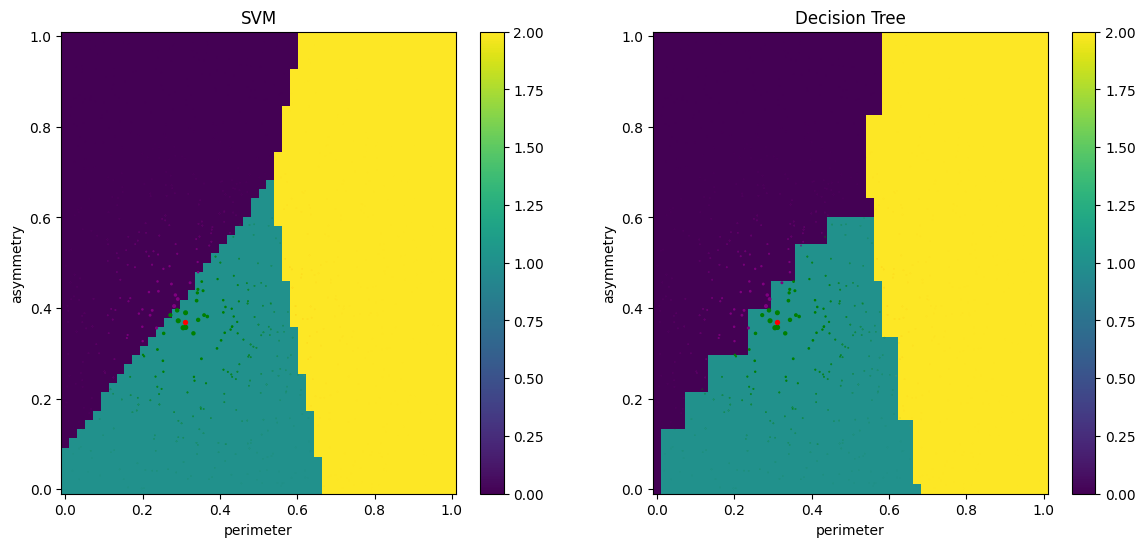

In [9]:
import sys
import os
import random
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
from utils.dataset import Dataset
import numpy as np
import itertools
from sklearn import tree
from math import sqrt

def get_grid(model, dataset, points_per_feature=50):
    """
    Retrieve grid data for plotting a two-dimensional graph with `points_per_feature` for each axis.
    The space is created by the hyperparameters' lower and upper values. Only the first two input
    labels are used.

    Parameters:
        model: Classifier which can call a predict method.
        dataset (utils.Dataset): Dataset with access to configspace and input labels.
        points_per_feature: How many points in each dimension.

    Returns:
        u (np.ndarray): x-axis points with shape (`points_per_feature`,).
        v (np.ndarray): y-axis points with shape (`points_per_feature`,).
        z (np.ndarray): Values with shape (`points_per_feature`, `points_per_feature`).
    """

    hps = dict(dataset.get_configspace())
    labels = dataset.get_input_labels()

    x1 = np.linspace(hps[labels[0]].lower,
                     hps[labels[0]].upper, points_per_feature)
    x2 = np.linspace(hps[labels[1]].lower,
                     hps[labels[1]].upper, points_per_feature)

    X = []
    for x in itertools.product(x1, x2):
        X.append(x)

    X = np.array(X)
    y = model.predict(X)

    # Reshape all x
    u = x1
    v = x2
    z = y.reshape(points_per_feature, points_per_feature).T

    return u, v, z


def plot_grid(u, v, z, labels, title=None, embedded=False):
    """
    Uses the grid data to add a color grid to the plot.

    Parameters:
        u (np.ndarray): x-axis points with shape (N,).
        v (np.ndarray): y-axis points with shape (N,).
        z (np.ndarray): Color values with shape (N, N).
        labels (list): Labels for x and y axis.
        embedded (bool): Whether a new figure should be created or not.

    Returns:
        plt (matplotlib.pyplot or utils.styled_plot.plt): Plot with applied color grid.
    """

    if not embedded:
        plt.figure()

    plt.xlabel(labels[0])
    plt.ylabel(labels[1])
    plt.title(title)

    plt.pcolormesh(u, v, z, cmap='viridis', shading='auto')
    plt.colorbar()
    plt.grid(alpha=0)

    return plt

def plot_points_in_grid(plt, Z=[], y=[], weights=None, colors={}, x_interest=None, size=8):
    """
    Given a plot, add scatter points from `Z` and `x_interest`.

    Parameters:
        plt (matplotlib.pyplot or utils.styled_plot.plt): Plot with color grid.
        Z (np.ndarray): Points with shape (?, 2) which should be added to the plot.
        y (np.ndarray): Target values with shape (?,), of the points added to the plot, determines the colouring of points.
        weights (np.ndarray): Normalized weights with shape (?,), determine the size of points in the plot.
        colors (dict): Returns the color for an y value.
        x_interest (np.ndarray): Single point with shape (2,) whose prediciton we want to explain. If None (default) no point is added.
        size (int): Default size of the markers/points. Default is 8.
    """

    w = 1

    for y_ in list(set(y)):
        idx = np.where(y == y_)[0]

        color = "black"
        if y_ in colors:
            color = colors[y_]

        if weights is not None:
            w = weights[idx]

        plt.scatter(Z[idx, 0], Z[idx, 1], c=color, s=w*size, label=y_)

    if x_interest is not None:
        plt.scatter([x_interest[0]], [x_interest[1]],
                    c='red', s=size, label="POI")


def sample_points(model, dataset, num_points, seed=0):
    """
    Samples points for the two first features. Uses the bounds from configspace again.

    Parameters:
        model: Classifier which can call a predict method.
        dataset (utils.Dataset): Dataset with access to configspace and input labels.
        num_points (int): How many points should be sampled.
        seed (int): Seed to feed random.

    Returns:
        X (np.ndarray): Data with shape (`num_points`, 2)
        y (np.ndarray): Target values with shape (`num_points`,)
    """

    random.seed(seed)

    hps = dict(dataset.get_configspace())
    labels = dataset.get_input_labels()

    Z = []
    for _ in range(num_points):
        Z.append((
            random.uniform(hps[labels[0]].lower, hps[labels[0]].upper),
            random.uniform(hps[labels[1]].lower, hps[labels[1]].upper)
        ))

    Z = np.array(Z)
    y = model.predict(Z)

    return Z, y


def weight_points(x_interest, Z, kernel_width=0.2):
    """
    For every z in `Z` returns a weight depending on the distance to `x_interest`.

    Parameters:
        x_interest (np.ndarray): Single point with shape (2,) whose prediction we want to explain.
        Z (np.ndarray): Points with shape (?, 2), data which needs to be weighted.
        kernel_width (float): kernel_width value to calculate distance according to exponential kernel.

    Returns:
        weights (np.ndarray): Normalized weights between 0..1 with shape (?,).
    """

    weights = []
    eucl = []
    for z in Z:
        eucl = sqrt(sum(np.square(z-x_interest)))
        dist = np.exp(-eucl/(kernel_width*kernel_width))
        weights.append(dist)

    weights = np.array(weights)

    # Normalize between 0 and 1
    weights = (weights - min(weights)) / (max(weights) - min(weights))

    return weights


def fit_explainer_model(Z, y, weights=None, seed=0):
    """
    Fits a decision tree.

    Parameters:
        Z (np.ndarray): Points with shape (?, 2), used to fit surrogate model.
        y (np.ndarray): Target values with shape (?,).
        weights (np.ndarray): Normalized weights with shape (?,).
        seed (int): Seed for the decision tree.

    Returns:
        model (DecisionTreeRegressor): Fitted explainer model.
    """

    explainer_model = tree.DecisionTreeRegressor(random_state=seed)
    explainer_model.fit(Z, y, sample_weight=weights)

    return explainer_model


if __name__ == "__main__":
    from sklearn.svm import SVC

    dataset = Dataset(
        "wheat_seeds", [1, 5], [7], normalize=True, categorical=True)
    (X_train, y_train), (X_test, y_test) = dataset.get_data()

    model = SVC(gamma = 'auto')
    model.fit(X_train, y_train)
    X = dataset.X
    s = 1

    x_interest = np.array([0.31, 0.37])
    points_per_feature = 50
    n_points = 1000
    labels = dataset.get_input_labels()
    colors = {
        0: "purple",
        1: "green",
        2: "orange",
    }

    print("Run `get_grid` ...")
    u, v, z = get_grid(
        model, dataset, points_per_feature=points_per_feature)

    print("Run `plot_grid` ...")
    plt = plot_grid(u, v, z, labels=labels, title="SVM")
    plt.show()

    print("Run `sample_points` ...")
    Z_sampled, y_sampled = sample_points(model, dataset, n_points)

    print("Run `plot_points_in_grid` ...")
    plt = plot_grid(u, v, z, labels=labels, title="SVM + Sampled Points")
    plot_points_in_grid(plt, Z_sampled, y_sampled, colors=colors)
    plt.show()

    print("Run `weight_points` ...")
    weights = weight_points(x_interest, Z_sampled)

    print("Run `plot_points_in_grid` ...")
    plt = plot_grid(u, v, z, labels=labels,
                    title="SVM + Weighted Sampled Points")
    plot_points_in_grid(plt, Z_sampled, y_sampled, weights, colors, x_interest)
    plt.show()

    print("Run `fit_explainer_model` ...")
    explainer = fit_explainer_model(Z_sampled, y_sampled, weights)

    print("Compare models ...")

    plt.subplot(1, 2, 1)
    plot_grid(u, v, z, labels=labels, title="SVM", embedded=True)
    plot_points_in_grid(plt, Z_sampled, y_sampled, weights, colors, x_interest)

    plt.subplot(1, 2, 2)
    u2, v2, z2 = get_grid(
        explainer, dataset, points_per_feature=points_per_feature)
    plot_grid(u2, v2, z2, labels=labels, title="Decision Tree", embedded=True)
    plot_points_in_grid(plt, Z_sampled, y_sampled, weights, colors, x_interest)

    # increase the width of the plot
    plt.gcf().set_size_inches(14, 6)

    plt.show()

### Hausaufgabe 1.4
Ihre Zielgruppe hat noch nie etwas von Entscheidungsbäumen gehört, stattdessen sind ihr Lineare Regressionen geläufig. Passen Sie den Code aus 1.3 entsprechend an und nutzen Sie eine lineare Regression. Stellen Sie in einem Feature Effects plot die Vorhersage des Surrogatmodells dar und beschreiben Sie die Ergebnisse kurz.